# SiPhox AIM PDK based Phase shifted Bragg grating refractive index sensor
Sarat Gundavarapu - 09/24/2025

`Key paper: https://opg.optica.org/oe/fulltext.cfm?uri=oe-17-17-15330:
P. Prabhathan, V. M. Murukeshan, Zhang Jing, and Pamidighantam V. Ramana, "Compact SOI nanowire refractive index sensor using phase shifted Bragg grating," Opt. Express 17, 15330-15341 (2009) https://doi.org/10.1364/OE.17.015330`

In [1]:
# ensure compatible versions of matplotlib and ipympl for widget backend

# basic imports
import numpy as np
import matplotlib.pyplot as plt
# Tidy3D imports
import tidy3d as td

In [2]:
# materials
n_si3n4 = 1.962735
n_pbs = 1.335
n_sio2 = 1.44834
wavelength0 = 1.31

Air = td.Medium(permittivity=1.0)
Si = td.Medium(permittivity=3.47**2)
si3n4 = td.Medium(permittivity=n_si3n4**2)
pbs = td.Medium(permittivity=n_pbs**2)
SiO2 = td.Medium(permittivity=n_sio2**2)

# geometric parameters
wg_height = 0.4
wg_feed_length = 1.0
wg_feed_width = 0.8
num_periods = 5
period = 0.4167
dc = 0.5

clad_thickness = 5.0
sub_thickness = 2.0

wg_length = num_periods * period + 2 * wg_feed_length
corrug_length = dc*period
wg_width = 0.8 #wg_feed_width - corrug_width
corrug_width = 0.2

freq0 = td.C_0 / wavelength0
fwidth = freq0 / 100.0
run_time = 5.0e-12
wavelength_min = td.C_0 / (freq0 + fwidth)
n2 = 1.656 # for pbs 1.33
n2 = 1.6566 # for pbs 1.335
shift = wavelength0 / (4 * n2)

wg1_y = wg2_y = 0

# waveguide 1
wg1_size = [td.inf, 
            wg_width, 
            wg_height]
wg1_center = [0, 
              0, 
              wg_height / 2]
wg1_medium = si3n4

sim_length = wg_length + 10 * period

# Lower and upper cladding
lower_clad = td.Structure(
    geometry=td.Box(center=[0, 0, -clad_thickness / 2], 
                    size=[td.inf, td.inf, clad_thickness]),
    medium=SiO2,
    name="lower_clad",
)

upper_clad_ox = td.Structure(
    geometry=td.Box(center=[0, 0, clad_thickness / 2], 
                    size=[td.inf, td.inf, clad_thickness]),
    medium=SiO2,
    name="upper_clad_ox",
)

upper_clad_pbs = td.Structure(
    geometry=td.Box(center=[0, 0, clad_thickness / 2], 
                    size=[wg_length, td.inf, clad_thickness]),
    medium=pbs,
    name="upper_clad_pbs",
)     
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
substrate = td.Structure(
    geometry=td.Box(center=[0, 0, -clad_thickness - sub_thickness / 2], 
                    size=[td.inf, td.inf, sub_thickness]),
    medium=Si,
    name="substrate",
)

# create the first waveguide
waveguide_1 = td.Structure(
    geometry=td.Box(center=wg1_center, size=wg1_size),
    medium=wg1_medium,
    name="waveguide_1",
)

# corrugation on the +y side
center = [-(0.5*dc*period + (1-dc)*period + 0.5*(dc*period+shift)),
          wg1_center[1], 
          wg1_center[2]]

corrug_plus = []
for i in range(num_periods//2):
    if i > 0:
        center[0] -= period
    plus = td.Structure(
        geometry=td.Box(center=center, 
                        size=[corrug_length, 
                              wg_width + corrug_width, 
                              wg_height]),
        medium=si3n4,
        name=f"corrug_plus_{i}",
    )

    corrug_plus.append(plus)

# Phase shifted Bragg grating
center[0] = 0
plus = td.Structure(
    geometry=td.Box(center=center, 
                    size=[period*dc+shift, 
                          wg_width + corrug_width, 
                          wg_height]),
    medium=si3n4,
    name=f"quarter_phase_shift",
)
corrug_plus.append(plus)

# corrugation on the +y side
center = [(0.5*dc*period + (1-dc)*period + 0.5*(dc*period+shift)),
          wg1_center[1], 
          wg1_center[2]]

for i in range(num_periods//2):
    if i > 0:
        center[0] += period
    plus = td.Structure(
        geometry=td.Box(center=center, 
                        size=[corrug_length, 
                              wg_width + corrug_width,
                              wg_height]),
        medium=si3n4,
        name=f"corrug_plus_{i+num_periods//2+1}",
    )

    corrug_plus.append(plus)

In [3]:
# simulation domain
sim_size = [sim_length, 4, 16]
sim_center = [0, 0, 0]
grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, 
                            wavelength=wavelength0)
boundary_spec = td.BoundarySpec.all_sides(boundary=td.PML())

# mode source for waveguide 1
source1_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth, amplitude=1)
mode_src1 = td.ModeSource(
    center=[-wg_length / 2 - period, wg1_y, wg_height / 2],
    size=[0, waveguide_1.geometry.size[1] * 2, waveguide_1.geometry.size[2] * 2],
    mode_index=0,
    direction="+",
    source_time=source1_time,
    mode_spec=td.ModeSpec(),
)

In [4]:
%matplotlib widget
# create monitors
monitor_xy = td.FieldMonitor(
    center=[0, 0, wg_height / 2],
    size=[wg_length, 2 * wavelength0 + wg_width + 2 * corrug_width, 0],
    freqs=[freq0],
    name="fields_xy",
)

freqs = np.linspace(freq0 - 2 * fwidth, freq0 + 2 * fwidth, 200)
monitor_flux_aligned = td.FluxMonitor(
    center=[wg_length / 2 + period, wg1_y, wg_height / 2],
    size=[0, waveguide_1.geometry.size[1] * 3, waveguide_1.geometry.size[2] * 5],
    freqs=freqs,
    name="flux_aligned",
)


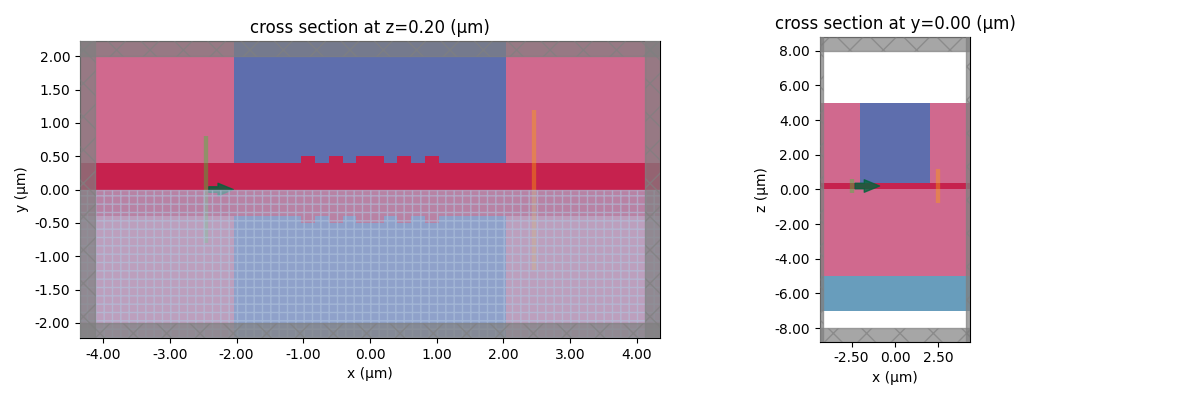

In [5]:
# list of all structures
structures = (
    [substrate, lower_clad, upper_clad_ox,upper_clad_pbs, waveguide_1]
    + corrug_plus
)

sources = [mode_src1]  # single source

monitors = [ monitor_flux_aligned, ]

# create the simulation
sim = td.Simulation(
    center=sim_center,
    size=sim_size,
    grid_spec=grid_spec,
    structures=structures,
    sources=sources,
    monitors=monitors,
    run_time=run_time,
    boundary_spec=boundary_spec,
    symmetry=(0,1,0)
)

# visualize simulation setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sim.plot(z=wg_height / 2, ax=ax1)
sim.plot(y=0, ax=ax2)
plt.tight_layout()
plt.show()


## Run Simulation

In [6]:
# run simulation
import tidy3d.web as web

sim_data = web.run(sim, task_name="bragg", path="data/bragg.hdf5", verbose=True)

14:38:52 Eastern Daylight Time Created task 'bragg' with task_id                
                               'fdve-7932299a-0f75-408b-a937-1dba9e553ad4' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=337197;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7932299a-0f75-408b-a937-1dba9e553ad4\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=938618;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7932299a-0f75-408b-a937-1dba9e553ad4\taskId]8;;\
                               ]8;id=337197;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7932299a-0f75-408b-a937-1dba9e553ad4\=]8;;\]8;id=837367;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7932299a-0f75-408b-a937-1dba9e553ad4\fdve]8;;\]8;id=337197;https://tidy3d.simulation.cloud/workbench?taskId=fdve-7932299a-0f75-408b-a937-1dba9e553ad4\-7932299a-0f75-408b-a937-1dba9e553ad4']8;;\.

                               Task folder: ]8;id=292889;https://tidy3d.simulation.cloud/folders/8993e9fd-16eb-42bd-a54a-7270ad3d7232\'default']8;;\.

Output()

14:39:00 Eastern Daylight Time Maximum FlexCredit cost: 1.093. Minimum cost     
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

14:39:01 Eastern Daylight Time status = success

Output()

14:39:05 Eastern Daylight Time loading simulation from data/bragg.hdf5

ValueError: dimensions ('f',) must have the same length as the number of data dimensions, ndim=0

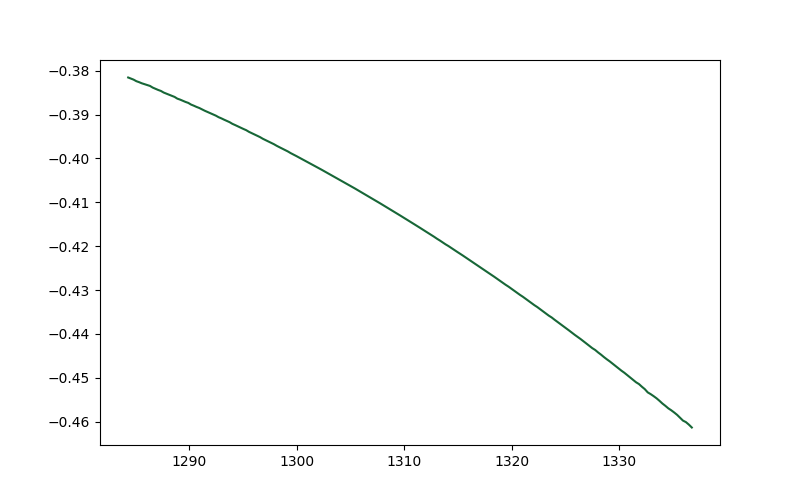

In [7]:
%matplotlib widget

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(td.C_0*1e3 / freqs, 10*np.log10(sim_data["flux_aligned"].flux))
# ax.plot(td.C_0 / freqs, sim_data["flux_misaligned"].flux, label="Misaligned corrugation")

# vertical line at design frequency
# ax.axvline(td.C_0 / freq0, ls="--", color="k")
# find peak wavelength and annotate
flux = sim_data["flux_aligned"].flux
idx_peak = np.argmax(flux)
lambda_um = td.C_0 / freqs[idx_peak]
lambda_nm = lambda_um * 1e3
x_peak = ax.lines[0].get_xdata()[idx_peak]
y_peak = 10 * np.log10(flux[idx_peak])

ax.axvline(x_peak, color='r', ls='--', label=f'Peak {lambda_nm:.1f} nm')
ax.annotate(f'{lambda_nm:.1f} nm', xy=(x_peak, y_peak),
            xytext=(10, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='r'),
            fontsize=9)

ax.set(xlabel="Wavelength (µm)", ylabel="Transmission")

ax.grid(True)
plt.legend()
plt.show()
